# Modeling — Hyperparameter Tuning

Tunes LightGBM and XGBoost with Optuna, then compares all models (baselines + defaults + tuned).

**Input:** `data/processed/ev_features.parquet`, `results/iteration_3/baseline_comparison.csv`  
**Output:** `results/iteration_3/model_comparison.csv`, `results/iteration_3/best_model.pkl`

### Memory-conscious adjustments (8GB M1 MacBook Air)
- Optuna tuning uses 50% subsample of training data
- 30 trials per model
- `gc.collect()` between sections
- Best params retrained on full training set once

## 0. Setup & Load

In [1]:
import warnings
import gc
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
sns.set_theme(style='whitegrid', palette='muted')

# Find project root
current = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [current, *current.parents]:
    if (candidate / 'data' / 'raw').exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise FileNotFoundError('Could not find the project root containing data/raw')

FEATURES_PATH    = PROJECT_ROOT / 'data' / 'processed' / 'ev_features.parquet'
BASELINE_PATH    = PROJECT_ROOT / 'results' / 'iteration_3' / 'baseline_comparison.csv'
RESULTS_DIR      = PROJECT_ROOT / 'results' / 'iteration_3'

print(f'Project root: {PROJECT_ROOT}')

Project root: /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project


/Users/alemz/micromamba/envs/pyclass/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(FEATURES_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

# Train/test split
SPLIT_DATE = pd.Timestamp('2022-07-01')

train = df[df['timestamp_hour'] < SPLIT_DATE].copy()
test  = df[df['timestamp_hour'] >= SPLIT_DATE].copy()

print(f'Train: {len(train):,} rows')
print(f'Test:  {len(test):,} rows')

# Define feature columns
EXCLUDE = ['customer_id', 'timestamp_hour', 'target', 'year']
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

X_train = train[FEATURE_COLS]
y_train = train['target']
X_test  = test[FEATURE_COLS]
y_test  = test['target']

# Subsample for tuning (50%)
TUNE_FRAC = 0.5
tune_idx = np.random.RandomState(42).choice(len(X_train), int(len(X_train) * TUNE_FRAC), replace=False)
tune_idx.sort()  # keep temporal order
X_tune = X_train.iloc[tune_idx]
y_tune = y_train.iloc[tune_idx]

# Validation split for tuning (last 10% of tuning subset)
tune_split = int(len(X_tune) * 0.9)
X_tune_tr, X_tune_val = X_tune.iloc[:tune_split], X_tune.iloc[tune_split:]
y_tune_tr, y_tune_val = y_tune.iloc[:tune_split], y_tune.iloc[tune_split:]

print(f'\nTuning subset: {len(X_tune):,} rows ({TUNE_FRAC*100:.0f}% of train)')
print(f'  Train: {len(X_tune_tr):,}  Val: {len(X_tune_val):,}')

del df
gc.collect()

Loaded: 7,229,089 rows × 40 cols
Train: 4,712,026 rows
Test:  2,517,063 rows

Tuning subset: 2,356,013 rows (50% of train)
  Train: 2,120,411  Val: 235,602


20

In [3]:
tuned_results = []

def evaluate_model(name, y_true, y_pred):
    """Compute metrics and append to results list."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mask = y_true > 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    row = {'Model': name, 'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape, 'R²': r2}
    tuned_results.append(row)
    print(f'{name:<30} MAE={mae:.4f}  RMSE={rmse:.4f}  MAPE={mape:.1f}%  R²={r2:.4f}')
    return row

## 1. Optuna Tuning — LightGBM

In [4]:
def lgbm_objective(trial):
    params = {
        'n_estimators': 500,
        'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'num_leaves':        trial.suggest_int('num_leaves', 16, 128),
        'max_depth':         trial.suggest_int('max_depth', 4, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':        trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1,
    }

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_tune_tr, y_tune_tr,
        eval_set=[(X_tune_val, y_tune_val)],
        callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(0)],
    )

    preds = model.predict(X_tune_val)
    return np.sqrt(mean_squared_error(y_tune_val, preds))


print('Tuning LightGBM (30 trials on 50% subsample)...')
lgbm_study = optuna.create_study(direction='minimize', study_name='lgbm')
lgbm_study.optimize(lgbm_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest RMSE: {lgbm_study.best_value:.4f}')
print(f'Best params: {lgbm_study.best_params}')

Tuning LightGBM (30 trials on 50% subsample)...


Best trial: 24. Best value: 6.60682: 100%|██████████| 30/30 [06:11<00:00, 12.39s/it]


Best RMSE: 6.6068
Best params: {'learning_rate': 0.03767382348598814, 'num_leaves': 57, 'max_depth': 4, 'min_child_samples': 16, 'subsample': 0.6146040282950377, 'colsample_bytree': 0.867211257209022, 'reg_alpha': 0.04540006573141637, 'reg_lambda': 7.77685056429803e-05}


In [5]:
# Retrain with best params on full training set
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

best_lgbm_params = {
    'n_estimators': 1000,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    **lgbm_study.best_params,
}

lgbm_tuned = lgb.LGBMRegressor(**best_lgbm_params)
lgbm_tuned.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(0)],
)

print(f'Best iteration: {lgbm_tuned.best_iteration_}')

y_pred_lgbm_tuned = lgbm_tuned.predict(X_test)
y_pred_lgbm_tuned = np.clip(y_pred_lgbm_tuned, 0, None)

evaluate_model('LightGBM (tuned)', y_test, y_pred_lgbm_tuned)

del X_tr, X_val, y_tr, y_val
gc.collect()

Best iteration: 524
LightGBM (tuned)               MAE=2.7789  RMSE=6.0040  MAPE=1435.1%  R²=0.5102


222

## 2. Optuna Tuning — XGBoost

In [6]:
def xgb_objective(trial):
    params = {
        'n_estimators': 500,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth':        trial.suggest_int('max_depth', 4, 12),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 50),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'early_stopping_rounds': 30,
        'random_state': 42,
        'n_jobs': -1,
        'verbosity': 0,
        'tree_method': 'hist',
    }

    model = xgb.XGBRegressor(**params)
    model.fit(
        X_tune_tr, y_tune_tr,
        eval_set=[(X_tune_val, y_tune_val)],
        verbose=False,
    )

    preds = model.predict(X_tune_val)
    return np.sqrt(mean_squared_error(y_tune_val, preds))


print('Tuning XGBoost (30 trials on 50% subsample)...')
xgb_study = optuna.create_study(direction='minimize', study_name='xgb')
xgb_study.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f'\nBest RMSE: {xgb_study.best_value:.4f}')
print(f'Best params: {xgb_study.best_params}')

Tuning XGBoost (30 trials on 50% subsample)...


Best trial: 28. Best value: 6.60052: 100%|██████████| 30/30 [09:25<00:00, 18.85s/it]


Best RMSE: 6.6005
Best params: {'learning_rate': 0.01603829463188278, 'max_depth': 7, 'min_child_weight': 19, 'subsample': 0.6732354331997502, 'colsample_bytree': 0.6483062796303868, 'reg_alpha': 0.0004742556610632753, 'reg_lambda': 0.0016620555309809605}


In [7]:
# Retrain with best params on full training set
split_idx = int(len(X_train) * 0.9)
X_tr, X_val = X_train.iloc[:split_idx], X_train.iloc[split_idx:]
y_tr, y_val = y_train.iloc[:split_idx], y_train.iloc[split_idx:]

best_xgb_params = {
    'n_estimators': 1000,
    'early_stopping_rounds': 50,
    'random_state': 42,
    'n_jobs': -1,
    'verbosity': 0,
    'tree_method': 'hist',
    **xgb_study.best_params,
}

xgb_tuned = xgb.XGBRegressor(**best_xgb_params)
xgb_tuned.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    verbose=False,
)

print(f'Best iteration: {xgb_tuned.best_iteration}')

y_pred_xgb_tuned = xgb_tuned.predict(X_test)
y_pred_xgb_tuned = np.clip(y_pred_xgb_tuned, 0, None)

evaluate_model('XGBoost (tuned)', y_test, y_pred_xgb_tuned)

del X_tr, X_val, y_tr, y_val
gc.collect()

Best iteration: 439
XGBoost (tuned)                MAE=2.7578  RMSE=5.9818  MAPE=1400.0%  R²=0.5138


7

## Overfitting Check
Compare train vs test metrics. If the model scores much better on training data, it's memorizing rather than learning.

In [8]:
# Overfitting check: train vs test metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

overfit_rows = []

for name, model in [('LightGBM (tuned)', lgbm_tuned), ('XGBoost (tuned)', xgb_tuned)]:
    # Train predictions
    y_pred_tr = np.clip(model.predict(X_train), 0, None)
    # Test predictions
    y_pred_te = np.clip(model.predict(X_test), 0, None)

    train_r2  = r2_score(y_train, y_pred_tr)
    test_r2   = r2_score(y_test, y_pred_te)
    train_mae = mean_absolute_error(y_train, y_pred_tr)
    test_mae  = mean_absolute_error(y_test, y_pred_te)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_tr))
    test_rmse  = np.sqrt(mean_squared_error(y_test, y_pred_te))

    overfit_rows.append({
        'Model': name,
        'Train R²': train_r2, 'Test R²': test_r2, 'R² Gap': train_r2 - test_r2,
        'Train MAE': train_mae, 'Test MAE': test_mae,
        'Train RMSE': train_rmse, 'Test RMSE': test_rmse,
    })

overfit_df = pd.DataFrame(overfit_rows)
print('=== Overfitting Check ===')
print(overfit_df.to_string(index=False))

for _, row in overfit_df.iterrows():
    gap = row['R² Gap']
    if gap < 0.03:
        verdict = 'No overfitting'
    elif gap < 0.07:
        verdict = 'Mild overfitting — acceptable'
    else:
        verdict = 'Overfitting detected — consider more regularization'
    print(f"\n{row['Model']}: R² gap = {gap:.4f} → {verdict}")

=== Overfitting Check ===
           Model  Train R²  Test R²    R² Gap  Train MAE  Test MAE  Train RMSE  Test RMSE
LightGBM (tuned)  0.505748 0.510161 -0.004414   2.601716  2.778890    5.587878   6.004042
 XGBoost (tuned)  0.514458 0.513791  0.000667   2.571992  2.757843    5.538418   5.981754

LightGBM (tuned): R² gap = -0.0044 → No overfitting

XGBoost (tuned): R² gap = 0.0007 → No overfitting


## 3. Final Comparison — All Models

=== Full Model Comparison ===
                Model      MAE     RMSE    MAPE (%)        R²
Persistence (lag 24h) 3.793285 8.740743 2168.945571 -0.038155
  Station Hourly Mean 3.247080 6.578715 2005.585172  0.411905
     Ridge Regression 3.143125 6.284335 2032.042979  0.463359
   LightGBM (default) 2.758632 5.986002 1403.803219  0.513101
    XGBoost (default) 2.759762 5.990005 1405.064218  0.512449
     LightGBM (tuned) 2.778890 6.004042 1435.060727  0.510161
      XGBoost (tuned) 2.757843 5.981754 1400.029340  0.513791


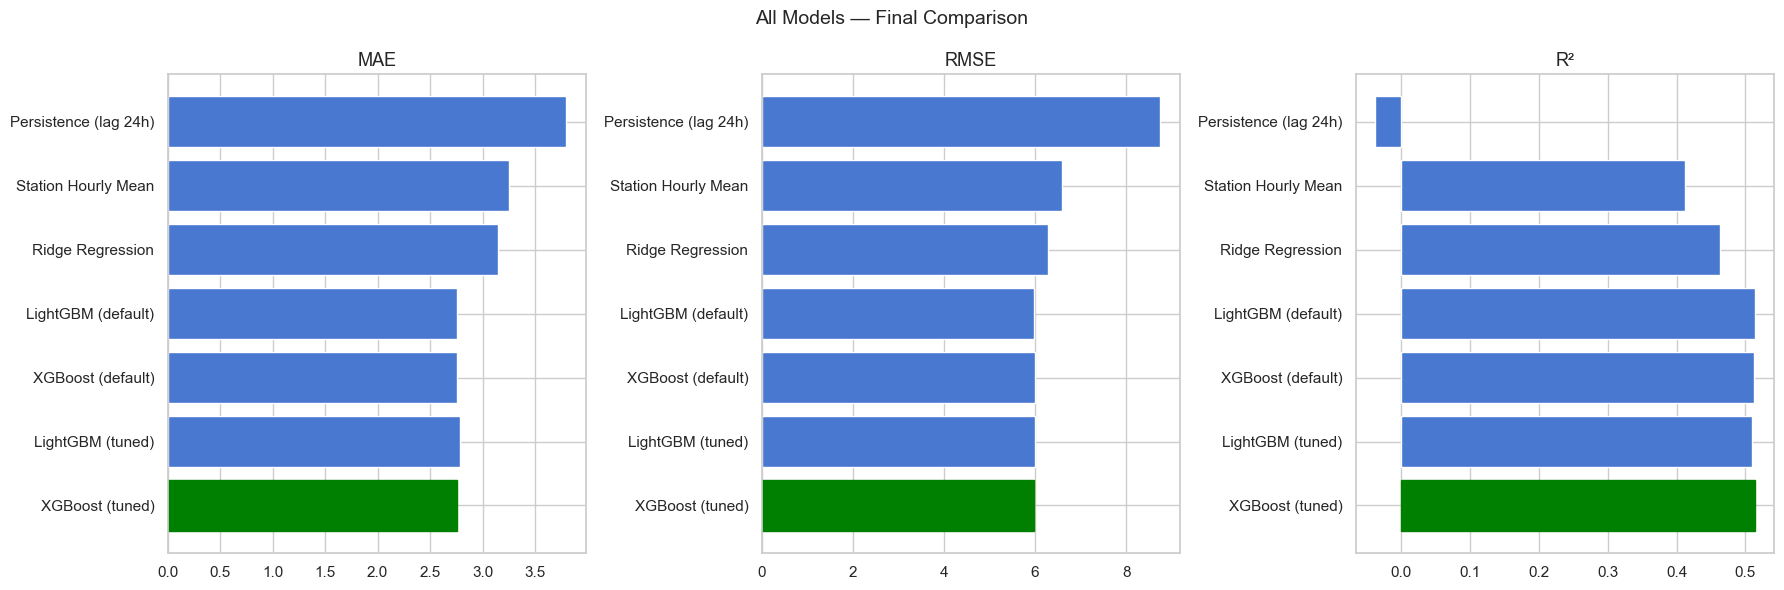

In [9]:
# Load baseline results and combine
baseline_df = pd.read_csv(BASELINE_PATH)
tuned_df = pd.DataFrame(tuned_results)
all_results = pd.concat([baseline_df, tuned_df], ignore_index=True)

print('=== Full Model Comparison ===')
print(all_results.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, metric in enumerate(['MAE', 'RMSE', 'R²']):
    bars = axes[i].barh(all_results['Model'], all_results[metric])
    axes[i].set_title(metric, fontsize=13)
    axes[i].invert_yaxis()

    # Highlight best
    if metric == 'R²':
        best_idx = all_results[metric].idxmax()
    else:
        best_idx = all_results[metric].idxmin()
    bars[best_idx].set_color('green')

plt.suptitle('All Models — Final Comparison', fontsize=14)
plt.tight_layout()
plt.show()

Best overall model: XGBoost (tuned)


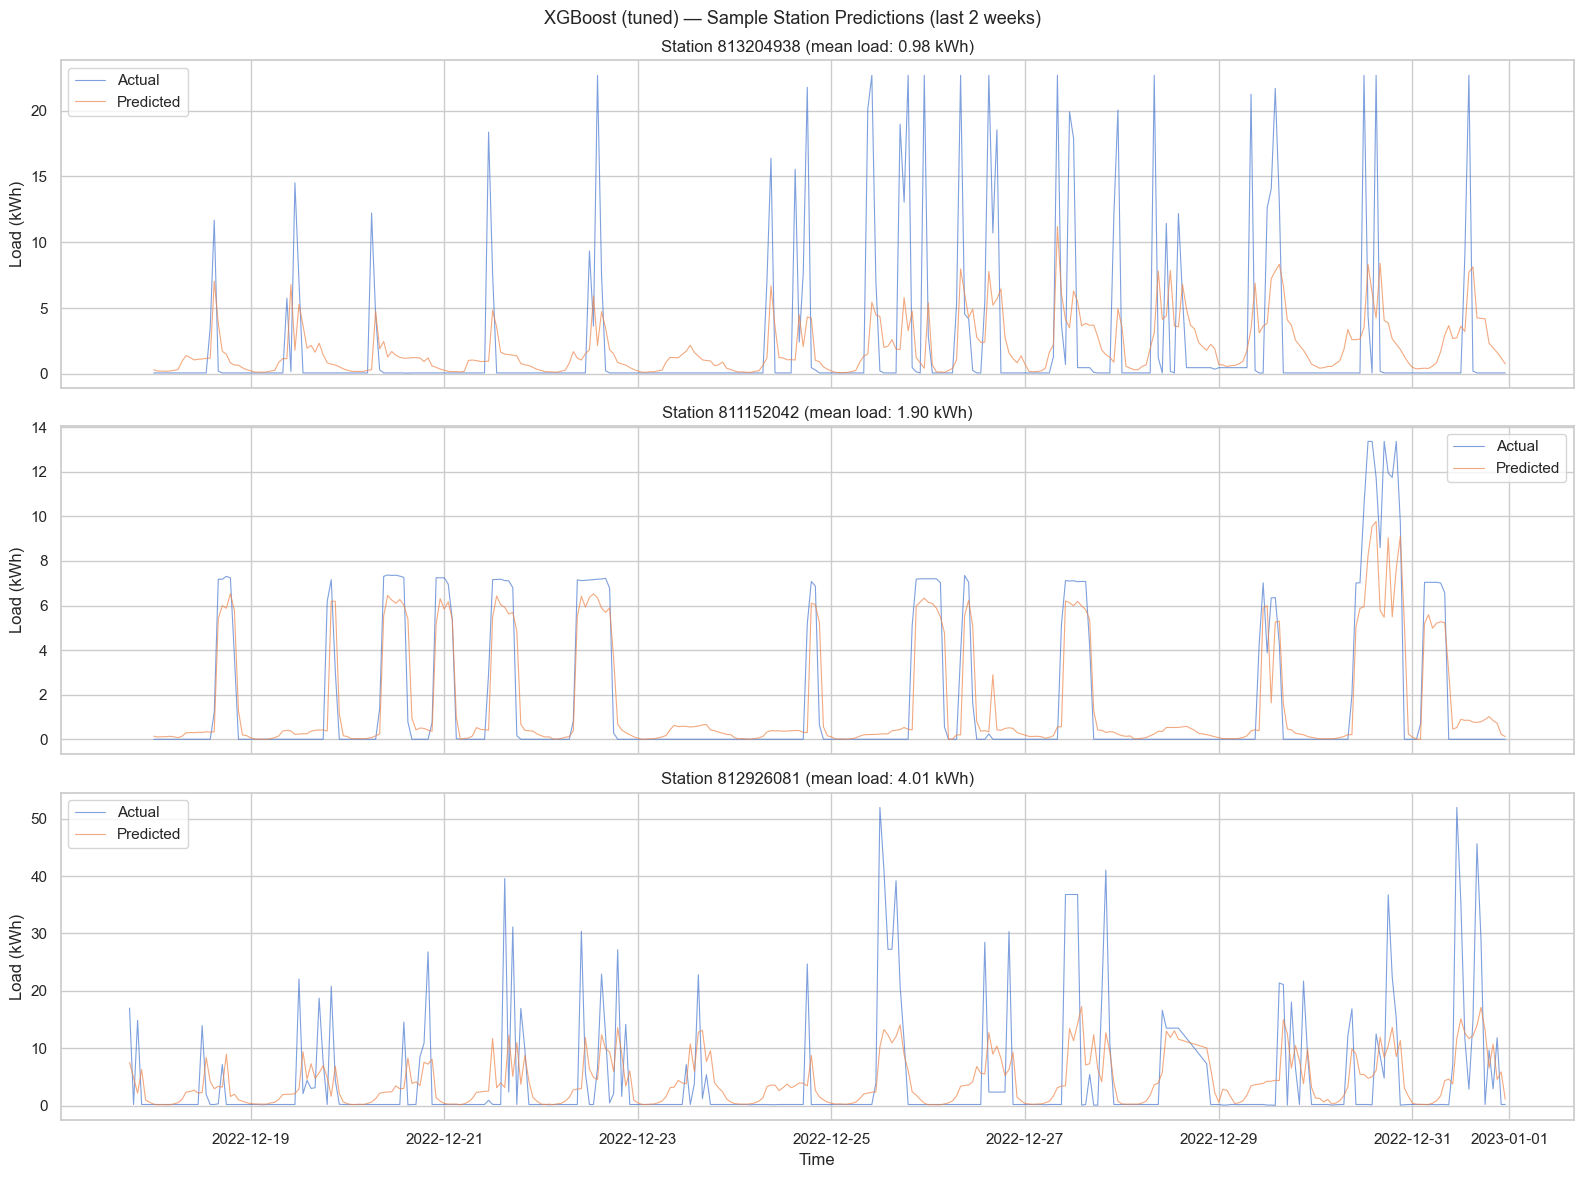

In [10]:
# Best model predictions on sample stations
best_name = all_results.loc[all_results['R²'].idxmax(), 'Model']
print(f'Best overall model: {best_name}')

# Get predictions for best model
if 'LightGBM (tuned)' == best_name:
    best_preds = y_pred_lgbm_tuned
else:
    best_preds = y_pred_xgb_tuned

# Sample stations
station_means = test.groupby('customer_id')['target'].mean().sort_values()
sample_stations = [
    station_means.index[len(station_means) // 4],
    station_means.index[len(station_means) // 2],
    station_means.index[3 * len(station_means) // 4],
]

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)

for i, station_id in enumerate(sample_stations):
    mask = test['customer_id'] == station_id
    ts = test.loc[mask, 'timestamp_hour'].values
    actual = test.loc[mask, 'target'].values
    predicted = best_preds[mask.values]

    n_show = min(24 * 14, len(ts))
    axes[i].plot(ts[-n_show:], actual[-n_show:], alpha=0.7, label='Actual', linewidth=0.8)
    axes[i].plot(ts[-n_show:], predicted[-n_show:], alpha=0.7, label='Predicted', linewidth=0.8)
    axes[i].set_title(f'Station {station_id} (mean load: {actual.mean():.2f} kWh)')
    axes[i].set_ylabel('Load (kWh)')
    axes[i].legend()

axes[-1].set_xlabel('Time')
plt.suptitle(f'{best_name} — Sample Station Predictions (last 2 weeks)', fontsize=13)
plt.tight_layout()
plt.show()

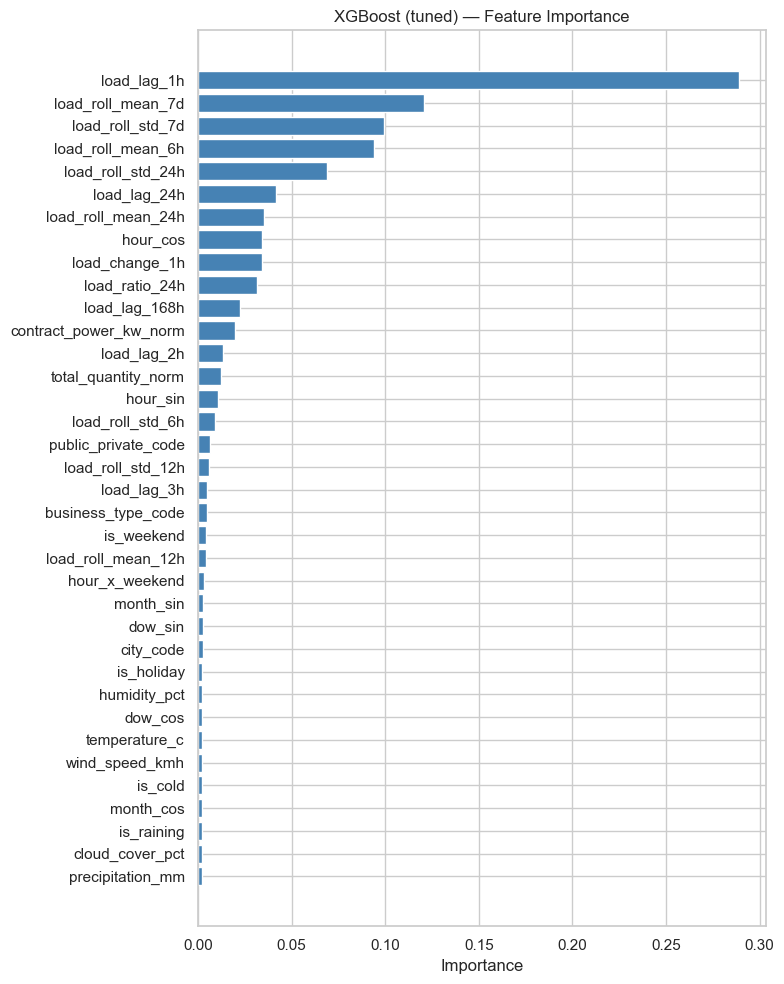

In [11]:
# Feature importance for best model
if 'LightGBM' in best_name:
    importances = lgbm_tuned.feature_importances_
else:
    importances = xgb_tuned.feature_importances_

importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(importance['feature'], importance['importance'], color='steelblue')
ax.set_title(f'{best_name} — Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 4. Save

In [12]:
# Save final comparison
all_results.to_csv(RESULTS_DIR / 'model_comparison.csv', index=False)
print(f'Saved comparison → {RESULTS_DIR / "model_comparison.csv"}')

# Save best model
if 'LightGBM' in best_name:
    best_model_obj = lgbm_tuned
else:
    best_model_obj = xgb_tuned

model_path = RESULTS_DIR / 'best_model.pkl'
joblib.dump(best_model_obj, model_path)
print(f'Saved best model ({best_name}) → {model_path}')

# Save Optuna studies
joblib.dump(lgbm_study, RESULTS_DIR / 'optuna_lgbm_study.pkl')
joblib.dump(xgb_study, RESULTS_DIR / 'optuna_xgb_study.pkl')
print(f'Saved Optuna studies → results/')



Saved comparison → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/results/iteration_3/model_comparison.csv
Saved best model (XGBoost (tuned)) → /Users/alemz/Desktop/Uni/Coding/Github/AI2_Project/results/iteration_3/best_model.pkl
Saved Optuna studies → results/

Done.
